## Enteric Fermentation Factor

Source: 2024 UGANDA’S SECOND BIENNIAL UPDATE REPORT TO THE UNITED NATIONS FRAMEWORK CONVENTION ON CLIMATE CHANGE Table 2-1: Tier 1 enhanced livestock characterisation and application of Emission Factors

In [45]:
import sys
dir_git = "/Users/usuario/git/sisepuede"
if dir_git not in sys.path:
    sys.path.append(dir_git)
    
import pandas as pd
import os
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np
import utils.common_data_needs as cdn

import sisepuede.utilities._toolbox as sf

In [82]:
import importlib
dict_ssp = cdn._setup_sisepuede_elements()

matt = dict_ssp.get("model_attributes", )
models = dict_ssp.get("models", )
regions = dict_ssp.get("regions", )
time_periods = dict_ssp.get("time_periods", )


# set the key model and export file name
_MODVAR_ENTFERM = matt.get_variable(models.model_afolu.modvar_lvst_ef_ch4_ef)
_MODVAR_POP = matt.get_variable(models.model_afolu.modvar_lvst_pop, )
_MODVAR_POP_INIT = matt.get_variable(models.model_afolu.modvar_lvst_pop_init, )
_FN_EXPORT = cdn.file_name_from_variable(_MODVAR_ENTFERM, )

# units manager
_UM_MASS = matt.get_unit("mass")

# build base input using latest data (will need some estimates for alignment)
uga_legacy_df = cdn._build_from_outputs(
    (
        min(time_periods.all_years), 
        max(time_periods.all_years)
    ),
    fns_exclude = [
        _FN_EXPORT
    ],
    force_complete_build = True, 
    merge_type = "outer", 
    print_info = False,
    stop_on_error = True, 
)

uga_legacy_df = time_periods.tps_to_years(
    uga_legacy_df,
)



In [5]:
# Set up paths
CURRENT_DIR_PATH = os.getcwd()
OUTPUT_DATA_DIR_PATH = os.path.join(CURRENT_DIR_PATH, "output_data")
INPUT_DATA_DIR_PATH = os.path.join(CURRENT_DIR_PATH, "input_data")
LVST_DATA_DIR_PATH = os.path.join(INPUT_DATA_DIR_PATH, "lvst")



In [72]:
# Load original uganda data
ef_lvst_entferm_legacy_df = _MODVAR_ENTFERM.get_from_dataframe(uga_legacy_df)
ef_lvst_entferm_legacy_df.head()

,ef_lvst_entferm_buffalo_kg_ch4_head,ef_lvst_entferm_cattle_dairy_kg_ch4_head,ef_lvst_entferm_cattle_nondairy_kg_ch4_head,ef_lvst_entferm_chickens_kg_ch4_head,ef_lvst_entferm_goats_kg_ch4_head,ef_lvst_entferm_horses_kg_ch4_head,ef_lvst_entferm_mules_kg_ch4_head,ef_lvst_entferm_pigs_kg_ch4_head,ef_lvst_entferm_sheep_kg_ch4_head
0,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0
1,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0
2,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0
3,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0
4,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0


# Enteric fermentation factors from BUR2 are displayed in Table 2-1; however, they do not line up with reported inventories and livestock population in Inventory Tables
- Inventories are much more compatible with lower-level factors shown in National Communication 3
- 14 million cattle * 31 kg CH4/head (low end, non-dairy) gives around $0.434 \text{MT}\, \text{CH}_4$, the inventory shows 0.4752 in NC3 and includes factors of 46 (dairy) and 31 (non-dairy)
- We will UPDATE the inventory tables to align with latest factors

In [73]:
uga_new_entferm_factors_df = pd.read_csv(os.path.join(LVST_DATA_DIR_PATH, "uganda_enteric_fermentation_emission_factors.csv"))
uga_new_entferm_factors_df

,lvst_category,system,emission_factor_kg_ch4_head
0,cattle_dairy,dairy cows,76.0
1,cattle_nondairy,multiple breeds,52.0
2,goats,high production system,9.0
3,goats,low production system,5.0
4,sheep,high production system,9.0
5,sheep,low production system,5.0
6,pigs,high production system,1.5
7,pigs,low production system,1.0
8,horses,NaN,0.0
9,buffalo,NaN,0.0


##  Get Cattle population breakdown of dairy vs. non-dairy
- Table 3.2 (page 72) of Livestock Census shows some breakdown by dairy/non-dairy

### Table in CSV matches this screenshot
![Cattle population distribtion, Table 3.2](input_data/ubos/livestock_survey_2021/ubos_lvst_survey_2021_table_3.2.png)

### Compute means and pivot table

In [74]:
new_factors_grouped_df = uga_new_entferm_factors_df.groupby("lvst_category")["emission_factor_kg_ch4_head"].mean().reset_index()


new_factors_grouped_df

,lvst_category,emission_factor_kg_ch4_head
0,buffalo,0.00
1,cattle_dairy,76.00
2,cattle_nondairy,52.00
3,chickens,0.00
4,goats,7.00
5,horses,0.00
6,mules,0.00
7,pigs,1.25
8,sheep,7.00


##  run SISEPUEDE to generate populations, then, in 2019 (Using BUR2):
1. Calculate upper-bound and lower-bound $\text{CH}_4$ emissions
2. find mix that aligns with BUR emission estimate


In [90]:
import warnings
warnings.filterwarnings("ignore")
df_proj = models.model_afolu(uga_legacy_df)

In [92]:
_CAT_LVST_CATTLE_DAIRY = "cattle_dairy"
_CAT_LVST_CATTLE_NONDAIRY = "cattle_nondairy"

field_dairy = _MODVAR_POP.build_fields(category_restrictions = _CAT_LVST_CATTLE_DAIRY)
field_nondairy = _MODVAR_POP.build_fields(category_restrictions = _CAT_LVST_CATTLE_NONDAIRY)


##  get populations of dairy and non-dairy
pop_dairy = float(
    df_proj[
        df_proj[time_periods.field_time_period]
        .isin([time_periods.year_to_tp(2019)])
    ]
    .get(field_dairy)
)

pop_nondairy = float(
    df_proj[
        df_proj[time_periods.field_time_period]
        .isin([time_periods.year_to_tp(2019)])
    ]
    .get(field_nondairy)
)

## get factors--nondairy includes multi-purpose
dict_cat_to_fact = sf.build_dict(
    new_factors_grouped_df[["lvst_category", "emission_factor_kg_ch4_head"]],
)


# set the scalar to convert the data units to modvar units
scalar_data_to_modvar = _UM_MASS.convert(
    "kg",
    _MODVAR_ENTFERM.attribute("unit_mass")
)


In [100]:
emissions_kg_dairy_2019 = dict_cat_to_fact.get(_CAT_LVST_CATTLE_DAIRY)
emissions_kg_nondairy_2019 = dict_cat_to_fact.get(_CAT_LVST_CATTLE_NONDAIRY)

# conver to KT to compare to inv
emissions_kt_dairy_2019 = emissions_kg_dairy_2019*pop_dairy/(10**9)
emissions_kt_nondairy_2019 = emissions_kg_nondairy_2019*pop_nondairy/(10**9)

# reasonable numbers from cows
emissions_kt_dairy_2019, emissions_kt_nondairy_2019

(0.228766232, 0.600555956)

In [108]:
#_MODVAR_ENTFERM.get_from_dataframe(uga_legacy_df
_MODVAR_POP.get_from_dataframe(df_proj, )

,pop_lvst_buffalo,pop_lvst_cattle_dairy,pop_lvst_cattle_nondairy,pop_lvst_chickens,pop_lvst_goats,pop_lvst_horses,pop_lvst_mules,pop_lvst_pigs,pop_lvst_sheep
0,0,2908490,11122508,46038999,15311999,12327,62368,3915999,3841999
1,0,2850825,10914441,47096551,15067928,11829,59851,4111082,4022644
2,0,2836700,10862257,49246171,15482607,11940,60410,4260762,4292277
3,0,2941969,11278483,51491404,16028266,12092,61181,4481657,4475124
4,0,3010082,11549153,46161918,16693841,12224,61852,4740928,4591197
5,0,3310465,12704435,54998872,18781943,13603,68828,6288352,4941036
6,0,3171875,12186909,54116135,18377301,12748,64503,5892711,5114793
7,0,3078859,11835941,55489349,17870649,12311,62288,6047028,4973845
8,0,3005555,11561320,57089122,17487328,11927,60346,6227333,4867232
9,0,3054736,11758677,58934296,17826692,12001,60727,6435605,4961774


In [102]:
# add year col
new_factors_grouped_df["year"] = 2015
new_factors_grouped_df

,lvst_category,emission_factor_kg_ch4_head,year
0,buffalo,0.00,2015
1,cattle_dairy,76.00,2015
2,cattle_nondairy,52.00,2015
3,chickens,0.00,2015
4,goats,7.00,2015
5,horses,0.00,2015
6,mules,0.00,2015
7,pigs,1.25,2015
8,sheep,7.00,2015


In [109]:
new_factors_pivot_df = new_factors_grouped_df.pivot(index="year", columns="lvst_category", values="emission_factor_kg_ch4_head").reset_index()
new_factors_pivot_df.columns.name = None
new_factors_pivot_df

,year,buffalo,cattle_dairy,cattle_nondairy,chickens,goats,horses,mules,pigs,sheep
0,2015,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0


In [110]:
# rename columns to match legacy df
for col in new_factors_pivot_df.columns:
    if col != "year":
        new_factors_pivot_df = new_factors_pivot_df.rename(columns={col: f"ef_lvst_entferm_{col.replace(' ', '_').lower()}_kg_ch4_head"})

new_factors_pivot_df

,year,ef_lvst_entferm_buffalo_kg_ch4_head,ef_lvst_entferm_cattle_dairy_kg_ch4_head,ef_lvst_entferm_cattle_nondairy_kg_ch4_head,ef_lvst_entferm_chickens_kg_ch4_head,ef_lvst_entferm_goats_kg_ch4_head,ef_lvst_entferm_horses_kg_ch4_head,ef_lvst_entferm_mules_kg_ch4_head,ef_lvst_entferm_pigs_kg_ch4_head,ef_lvst_entferm_sheep_kg_ch4_head
0,2015,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0


In [111]:
# Copy rows until 2100
years_to_add = list(range(2015, 2101))
new_factors_full_df = pd.concat([new_factors_pivot_df]*len(years_to_add), ignore_index=True)
new_factors_full_df["year"] = years_to_add
new_factors_full_df

,year,ef_lvst_entferm_buffalo_kg_ch4_head,ef_lvst_entferm_cattle_dairy_kg_ch4_head,ef_lvst_entferm_cattle_nondairy_kg_ch4_head,ef_lvst_entferm_chickens_kg_ch4_head,ef_lvst_entferm_goats_kg_ch4_head,ef_lvst_entferm_horses_kg_ch4_head,ef_lvst_entferm_mules_kg_ch4_head,ef_lvst_entferm_pigs_kg_ch4_head,ef_lvst_entferm_sheep_kg_ch4_head
0,2015,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0
1,2016,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0
2,2017,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0
3,2018,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0
4,2019,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0
...,...,...,...,...,...,...,...,...,...,...
81,2096,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0
82,2097,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0
83,2098,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0
84,2099,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0


### Validation

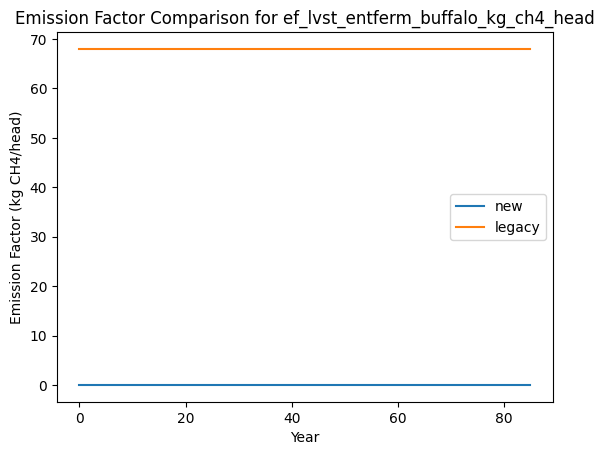

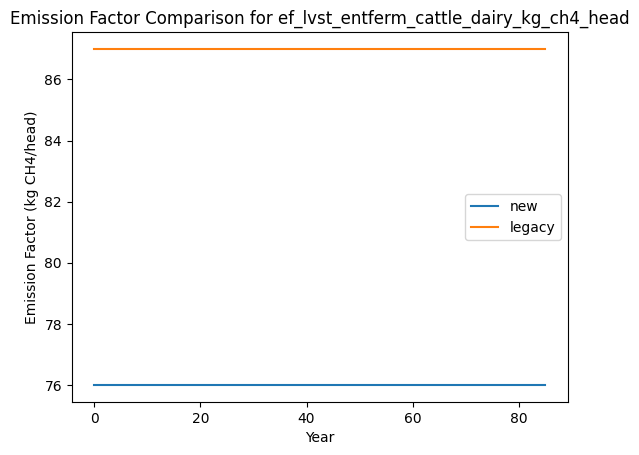

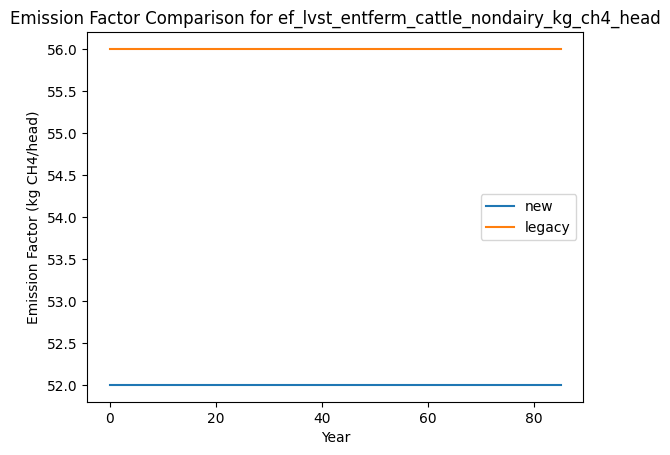

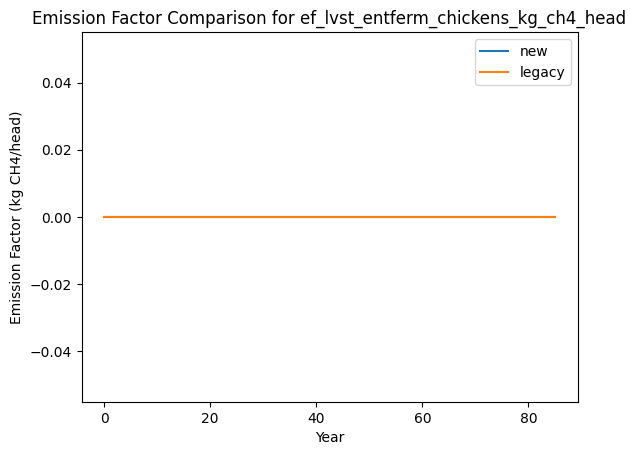

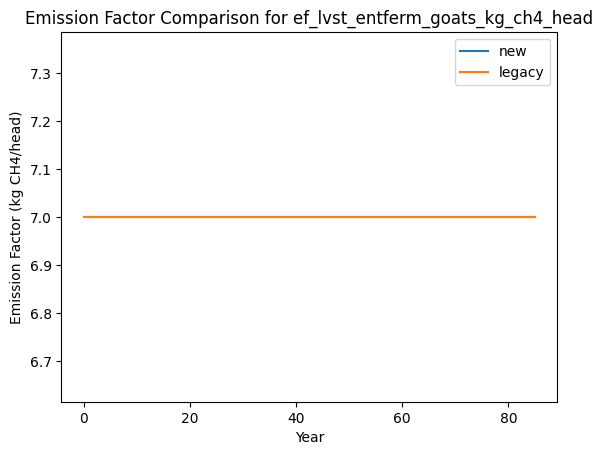

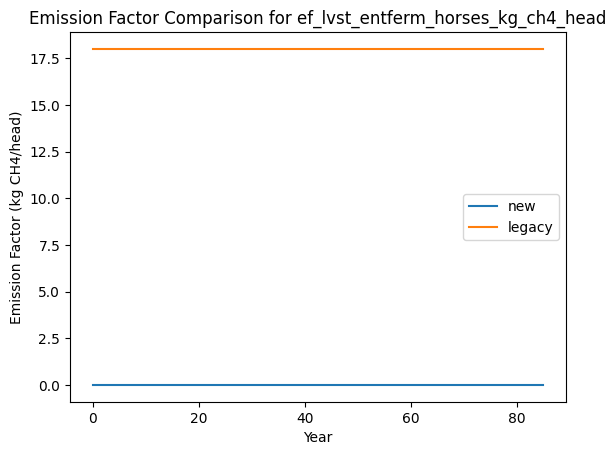

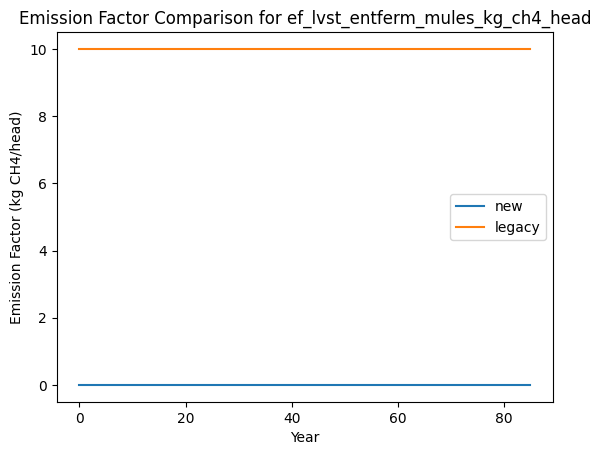

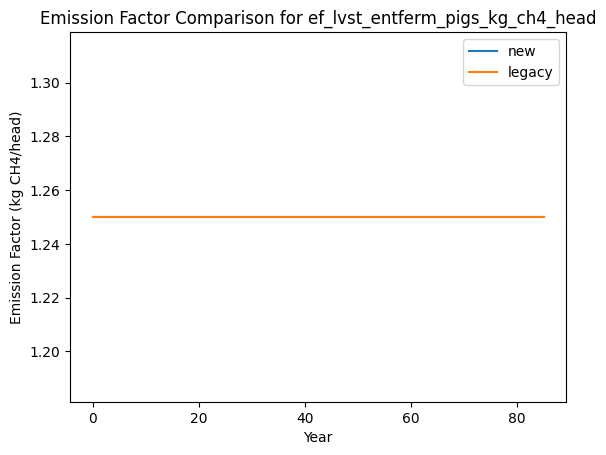

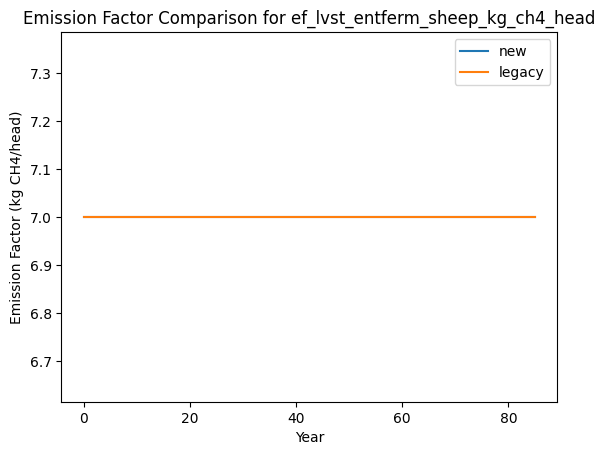

In [11]:
for col in new_factors_full_df.columns:
    if col != "year":
        plt.plot(new_factors_full_df[col], label="new")
        plt.plot(ef_lvst_entferm_legacy_df[col], label="legacy")
        plt.xlabel("Year")
        plt.ylabel("Emission Factor (kg CH4/head)")
        plt.title(f"Emission Factor Comparison for {col}")
        plt.legend()
        plt.show()

In [113]:
# Save to output dir
new_factors_full_df.to_csv(
    os.path.join(OUTPUT_DATA_DIR_PATH, _FN_EXPORT), index=False)

'CH4_ENTERIC_FERMENTATION_EMISSION_FACTOR.csv'